In [102]:
import numpy as np
import scipy
import scipy.sparse
import scipy.sparse.linalg
import matplotlib
import matplotlib.cm
import matplotlib.pyplot as plt

import cnetwork
from cnetwork import p_lithostatic, T_geothermal, MagmaChamber, GlobalSystem, GlobalSystemThreshold

In [103]:
# Set Maxwell times
t_b = 1e11
t_d = 5e10
K_crust = 10e9
G_crust = 10e9
K_f = 10e9
rho0 = 2500

# Constant viscosity assumption
mu0 = 1e6
# Effective hydraulic radius
r_hydr = 5

# Fix total volume
total_vol = (4/3)*np.pi*1000.0**3
# Fix mass injection
mass_inj = total_vol * rho0 * 0.001

# Network parameters
N_chamber = 10
x_scale = 10000.0
y_scale = 0.0
z_scale = 40000.0 # Depth

In [104]:
# Random distribution
np.random.seed(0)

# Set limits of characteristic size of chamber
R_min = 500
R_max = 500
# Uniformly randomly distribution volume
V_min = (4/3)*np.pi*R_min**3
V_max = (4/3)*np.pi*R_max**3

# List generation of chamber characteristics
x_nodes = 0.0 * np.random.rand(N_chamber)
y_nodes = 0.0 * np.random.rand(N_chamber)
z_nodes = np.linspace(0.0, z_scale, N_chamber)
V_nodes = V_min + (V_max - V_min) * np.random.rand(N_chamber)

# Characteristic node separation distance
node_sep = z_scale/(N_chamber - 1)

# Symmetric distance matrix
d = np.sqrt((x_nodes - x_nodes[:,np.newaxis]) ** 2
     + (y_nodes - y_nodes[:,np.newaxis]) ** 2
     + (z_nodes - z_nodes[:,np.newaxis]) ** 2)

list_nodes = [MagmaChamber(
                    x=x,
                    y=y,
                    z=z,
                    p_setting=None,
                    T_setting=1200,
                    V_setting=V)
              for (x,y,z,V) in zip(x_nodes, y_nodes, z_nodes, V_nodes)]

In [105]:
# Set up for timestepping later
global_sys = GlobalSystemThreshold(list_nodes, t_b, t_d, K_crust, G_crust,
                                   r_hydr=r_hydr, mu0=mu0, 
                                   rho0=2500, K_f=K_f, Nr=50,
                                   dpdx_crit=1e3,
                                   dpdx_threshold_scale=0.0,#1e2,
                                   R_outer_ratio=20, max_edge_dist=1.1*node_sep)

q0 = global_sys.q0

# Compute initial L, M(q0), f
L, M, f = global_sys.assemble_global_LMf(q0)


In [106]:
# Set mass rate for injection
mdot_inj = 30.0
# Add source term for injection
f_inj = 0.0 * f
f_inj[global_sys.data_slice_global(0, "mass")] = mdot_inj

# Eruption parameters
r_conduit = 25
mu_erupt = 1e5
# Overpressure required for eruption
p_erupt = 5e6

In [107]:
import percolation_network
rg = percolation_network.RandomGraph(global_sys.nodes, max_edge_dist=1.1*node_sep)

In [108]:
# Gaussian mass-rate-in function
def gaussian(x, scale=1, mass=1, shift=0.0):
  return np.exp(-0.5 * ((x - shift)/scale)**2) / np.sqrt(2 * np.pi) * mass/scale

mass_in_fn = lambda t: gaussian(t, scale=1e9, mass=5e9, shift=5e9)

In [109]:
''' Timestepping '''

# Time vector
N_t:int=3000 * 10
t_vec = None
if t_vec is None:
  t1 = 3e10 * 20
  t_vec = np.linspace(0, t1, N_t)

# Start q with initial condition
q = q0.copy()
# Allocate full output storage
q_out = np.zeros((t_vec.size, *q.shape))
# Save last dt for cache check
dt = np.nan
dt_last = np.nan
dt_last_last = np.nan
# Max order possible
max_order = np.ones(t_vec.size, dtype=int)

global_sys._step_strategy = np.zeros(t_vec.size, dtype=float)
L, M, f = global_sys.assemble_global_LMf(q)
# lu_out = scipy.sparse.linalg.splu(scipy.sparse.eye(global_sys.num_dof) + 0.5 * dt * L)

m_erupted = 0.0
m_erupted_out = np.zeros((t_vec.size,))

for i, t in enumerate(t_vec):
  if i > 0:
    # Compute timestep
    dt = t_vec[i] - t_vec[i-1]

    M = global_sys.assemble_global_LMf(q, skip_Lf=True)

    # Strang split      
    # q = scipy.sparse.linalg.spsolve(scipy.sparse.eye(global_sys.num_dof) + dt * L, q + f * dt)

    # f_inj = 0.0 * f
    # f_inj[global_sys.data_slice_global(0, "mass")] = mass_in_fn(t)

    p_node = global_sys.pressure(q)
    
    deltap = (p_node[-1] - global_sys.nodes[-1].p0) - p_erupt
    f_erupt = 0.0 * f_inj
    if deltap > 0:
      eruption_rate = global_sys.rho0 * (deltap / (16.0 * mu_erupt)) * r_conduit * r_conduit * r_conduit
      # Eruption rate limiter for first-order Euler
      max_eruption_rate = (q[global_sys.data_slice_global(-1, "mass")] - global_sys.nodes[-1].m0) / dt
      if eruption_rate > max_eruption_rate:
        eruption_rate = max_eruption_rate
      # Set eruption rate in mass conservation equation
      f_erupt[global_sys.data_slice_global(-1, "mass")] = -eruption_rate
      # Integrate erupted mass
      m_erupted += eruption_rate * dt

    # Quasi-implicit one-step solve (strictly M(q^n) is used instead of M(q^n+1))
    q = scipy.sparse.linalg.spsolve(scipy.sparse.eye(global_sys.num_dof) + dt * (L + M), q + dt * (f + f_inj + f_erupt))[:,np.newaxis]

    if False:
      # (1/3) BDF1, update matrix inv(I + dt*L)
      # lu_out = scipy.sparse.linalg.splu(scipy.sparse.eye(global_sys.num_dof) + 0.5 * dt * L)
      q = lu_out.solve(q + f * 0.5 * dt)
      # (2/3) Semi-BDF1, update matrix (approximate threshold explicitly, not implicitly)
      q = scipy.sparse.linalg.spsolve(scipy.sparse.eye(global_sys.num_dof) + dt * M, q)[:,np.newaxis]
      # (3/3) BDF1, update matrix inv(I + dt*L)
      q = lu_out.solve(q + f * 0.5 * dt)
      global_sys._step_strategy[i] = 1.0

    if False:
      if method == 2 and np.isclose(dt, dt_last) and not np.isclose(dt_last_last, dt_last):
        # BDF2, update matrix
        lu_out = scipy.sparse.linalg.splu(scipy.sparse.eye(global_sys.num_dof) + (2.0/3.0) * dt * L)
        q = lu_out.solve((4.0/3.0) * q + (2.0/3.0) * f * dt - (1.0/3.0) * q_out[i-2,...])
        global_sys._step_strategy[i] = 2.0
      elif method == 2 and np.isclose(dt, dt_last) and np.isclose(dt_last_last, dt_last):
        # BDF2, use cached matrix
        q = lu_out.solve((4.0/3.0) * q + (2.0/3.0) * f * dt - (1.0/3.0) * q_out[i-2,...])
        global_sys._step_strategy[i] = 2.5
      elif not np.isclose(dt, dt_last):
        # BDF1, update matrix inv(I + dt*L)
        lu_out = scipy.sparse.linalg.splu(scipy.sparse.eye(global_sys.num_dof) + dt * L)
        q = lu_out.solve(q + f * dt)
        global_sys._step_strategy[i] = 1.0
      else:
        # BDF1, use cached matrix inv(I + dt*L)
        q = lu_out.solve(q + f * dt)
        global_sys._step_strategy[i] = 1.5

  dt_last_last = dt_last
  dt_last = dt
  q = np.reshape(q, (q.size, 1))
  # Save result
  q_out[i,...] = q
  m_erupted_out[i] = m_erupted


In [110]:
# Write source term f as diagonal matrix
F_diag = np.diag(np.array((f + f_inj + f_erupt)[global_sys.mass_indices].todense()).squeeze())

# Extract mass sources
F_diag = scipy.sparse.diags(
  (f + f_inj + f_erupt)[global_sys.mass_indices].toarray().squeeze())
# Construct mass transfer matrix
mm = global_sys.mass_rates(q) + F_diag
# Check that the mass transfer matrix sums to dm/dt
M = global_sys.assemble_global_LMf(q, skip_Lf=True)
dqdt = (f + f_inj + f_erupt) - (L + M) @ q
mm.todense().sum(axis=1).T, dqdt[global_sys.mass_indices].T

(matrix([[ 1.2058894 ,  0.94636912,  0.7415306 ,  0.57604285,  0.44068942,
           0.32999083,  0.21973909,  0.06014892,  1.45252225, 24.02707753]]),
 matrix([[ 1.2058894 ,  0.94636912,  0.7415306 ,  0.57604285,  0.44068942,
           0.32999083,  0.21973909,  0.06014892,  1.45252225, 24.02707753]]))

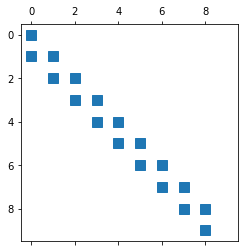

In [111]:
plt.spy(global_sys.mass_rates(q))

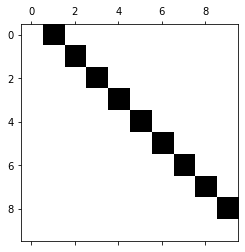

In [112]:
plt.spy(global_sys.get_connectivity(q))

(array([1.95992832e-11, 2.16548836e-11, 2.38500670e-11, 2.62081813e-11,
        2.87527822e-11, 3.15070732e-11, 3.45217632e-11, 3.79293980e-11,
        3.92661325e-11, 0.00000000e+00]),
 array([[0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.1],
        [1. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.1],
        [0. , 1. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.1],
        [0. , 0. , 1. , 0. , 0. , 0. , 0. , 0. , 0. , 0.1],
        [0. , 0. , 0. , 1. , 0. , 0. , 0. , 0. , 0. , 0.1],
        [0. , 0. , 0. , 0. , 1. , 0. , 0. , 0. , 0. , 0.1],
        [0. , 0. , 0. , 0. , 0. , 1. , 0. , 0. , 0. , 0.1],
        [0. , 0. , 0. , 0. , 0. , 0. , 1. , 0. , 0. , 0.1],
        [0. , 0. , 0. , 0. , 0. , 0. , 0. , 1. , 0. , 0.1],
        [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 1. , 0.1]]))

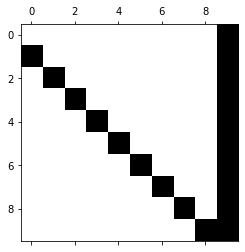

In [113]:
# Compute turnover rates mdot / m
turnover_rates = scipy.sparse.diags(1/q[global_sys.mass_indices].squeeze()) @ global_sys.mass_rates(q)
out_rates = scipy.sparse.lil_matrix(turnover_rates)
out_rates[np.arange(0, global_sys.num_blocks), np.arange(0, global_sys.num_blocks)] = 0.0

# Instantaneous Poisson rates
poisson_lambda = np.array(out_rates.sum(axis=0)).squeeze()
# Probability of escaping from node j to node i given that particle escapes
path_probability = np.full(out_rates.shape, 1 / global_sys.num_blocks)
np.divide(out_rates.toarray(), poisson_lambda, where=poisson_lambda!=0, out=path_probability)
plt.spy(path_probability)

poisson_lambda, path_probability

In [114]:
''' Graph walking '''

# Initialize a number of particles at node 0
N_particles = 10000
curr_node = np.full((N_particles,), 0, dtype=int)
# Allocate node location history for each particle
node_location = np.full((t_vec.size, N_particles), -1, dtype=int) 

for i, t in enumerate(t_vec):
  # Load q, pressure from ODE solution
  q = q_out[i,...]
  p_node = global_sys.pressure(q)

  # Compute turnover rates mdot / m
  turnover_rates = scipy.sparse.diags(1/q[global_sys.mass_indices].squeeze()) @ global_sys.mass_rates(q)
  out_rates = scipy.sparse.lil_matrix(turnover_rates)
  out_rates[np.arange(0, global_sys.num_blocks), np.arange(0, global_sys.num_blocks)] = 0.0
  # Instantaneous Poisson rates
  poisson_lambda = np.array(out_rates.sum(axis=0)).squeeze()
  # Probability of escaping from node j to node i given that particle escapes
  path_probability = np.full(out_rates.shape, 1 / global_sys.num_blocks)
  np.divide(out_rates.toarray(), poisson_lambda, where=poisson_lambda!=0, out=path_probability)
  # Probability of exiting in current timestep
  prob = poisson_lambda[curr_node] * dt
  # End walk at last node
  prob[-1] = 0

  # Determine whether each particle exits node
  exit_roll = np.random.rand(N_particles) < prob
  # Choose exit path based on probability
  new_node = (np.random.rand(N_particles)[np.newaxis,:]
              < np.cumsum(path_probability[:,curr_node], axis=0)).argmax(axis=0)
  curr_node = np.where(exit_roll, new_node, curr_node)
  node_location[i,:] = curr_node

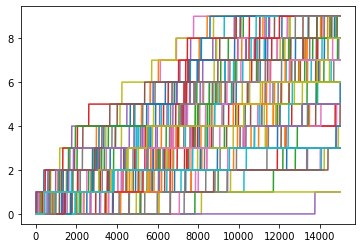

In [116]:
plt.plot(node_location[:,:100]);

Text(0.5, 0, 'Node index')

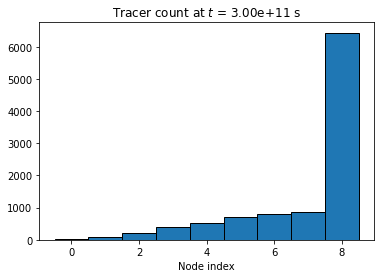

In [117]:
plt.hist(node_location[-1,:]-.5, bins=np.arange(0,node_location.max()+1)-.5,
         edgecolor='black')
plt.title(f"Tracer count at $t$ = {t_vec[-1]:.2e} s")
plt.xlabel("Node index")

In [148]:
loc_quants = np.quantile(node_location, [0.25, 0.5, 0.75], axis=1)

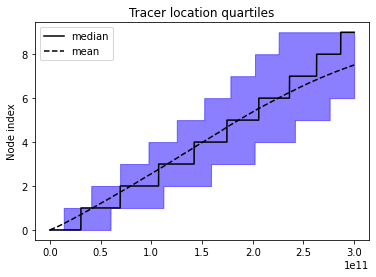

In [155]:
loc_mean = node_location.mean(axis=1)
loc_std = node_location.std(axis=1)

plt.plot(t_vec, loc_quants[1,:], 'k-', label="median")
plt.plot(t_vec, loc_mean, 'k--', label="mean")
plt.fill_between(t_vec, loc_quants[0,:], loc_quants[2,:], color=[0.1, 0, 1.0, 0.5])
plt.ylabel("Node index")
plt.title("Tracer location quartiles")
plt.legend()

In [119]:
(np.random.rand() < np.cumsum(path_probability[:,curr_node])).argmax()


21

In [120]:
poisson_lambda[curr_node]

array([3.79293980e-11, 3.79293980e-11, 3.79293980e-11, ...,
       0.00000000e+00, 3.92661325e-11, 1.95992832e-11])

In [121]:
# Post-process with output size (n_t, n_chambers, (N_r))
m, p, sigmas, u = global_sys.post_process(t_vec, q_out)

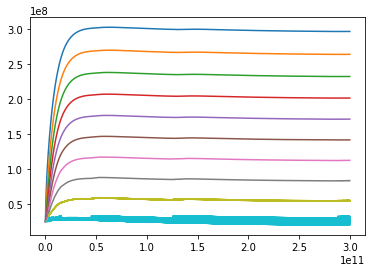

In [122]:
plt.plot(t_vec, p)

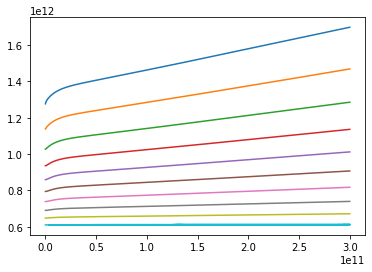

In [123]:
plt.plot(t_vec, m)